In [1]:
#################################################################################
# Main script to run UP-MAVT analysis
#
# Simone Pagliuca, 2025-2026
#
# Description:
# TBC....
#################################################################################

#################################################################################
# Import third party libraries
import numpy as np
# import matplotlib
# matplotlib.use('TkAgg')  # Set backend before importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
#################################################################################

#################################################################################
# Import internal modules
from pile_bwt import bwt, constraints_func
from up_mavt import startup, mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import obtain_weight_space_description
#################################################################################

#################################################################################
# USER INPUTS
# Weight elicitation files (one per elicitation / run)
file_path_weight_elicitations = ["wbt_results_1.csv"]

# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv"]

# Criteria definitions file
file_path_criteria = "criteria.csv"

# Montecarlo Parameters
n_runs = 10000
PLOTS = True  # Toggle plots
UPDATE_EVERY = 10  # Update plots every N runs
#################################################################################


#################################################################################
# Startup: Load all data
dict_data_list, crit_index, vf_list, alternatives = startup(file_path_criteria, file_path_weight_elicitations, file_path_value_functions)
n_alternatives = len(alternatives)
print(f"Loaded {len(dict_data_list)} elicitation(s) with {n_alternatives} alternatives.")
#################################################################################


Number of criteria identified: 15
Loading criteria definitions and attaching value functions...
Starting loop over weight elicitation files...
Processing file 1/1: wbt_results_1.csv
Loaded 1 elicitation(s) with 6 alternatives.


In [2]:

#################################################################################
# PILE-BWT Method
# 
# Work in progress while we try to fix issues with constraints and solver
# For now it runs the BWT optimization and then tries to sample more values from the space
print("Running BWT for each elicitation...")
bwt_results = []

for i, dict_data in enumerate(dict_data_list):
    print(f"Running BWT for elicitation {i+1}...")  # Debugging: Print elicitation index
    bwt_result = bwt(dict_data)
    bwt_results.append(bwt_result)
    
print(bwt_result["solver_result"])



Running BWT for each elicitation...
Running BWT for elicitation 1...
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=4.62013377156012e-06
COBYLA produced near-feasible solution: accepting result.
 message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.
 success: True
  status: 0
     fun: 5.350096186475808
       x: [ 3.117e-02  5.829e-02 ...  1.341e-01  5.350e+00]
    nfev: 388
   maxcv: 4.62013377156012e-06


In [3]:

print("\033[93mTesting with BWT results...\033[0m")
x_weights = bwt_result["solver_result"]["x"][:-1]
x_temp = np.concatenate([x_weights, [0]])
constraint_value = constraints_func(x_temp, dict_data)
error_b = min(max([abs(cv) for cv in constraint_value]), 10)
for c in constraint_value:
    c_py = float(c)
    print(c_py)  # Debugging: print as native Python float
print(f"\033[91mMaximum constraint violation (error_b): {error_b}\033[0m")  # Debugging
known_max_error = error_b
print("\n")
print(x_weights)


Testing with BWT results...
-0.45112775289823503
-2.1422077363716117
-1.1144681030210037
-0.240410774082348
-4.879980794641314
-4.1327887743775875
-5.143517149604129
-1.7863288809029851
-5.299907357261256
-5.350095335045857
-5.350100806609579
-0.28484268473008856
-5.350096223386983
-0.6967367619039591
-1.4482898295987199
-0.020074545409403344
-0.13743333904247734
-2.402040795658179
-3.2629310051814127
-1.4843045337111993
-0.25763170042249306
-1.294934390618806
-0.7407575996280864
-2.5754976180142113
-2.6653691686963374
-2.217024014672003
-2.9307058127389674
-3.456496118547978
Maximum constraint violation (error_b): 5.350100806609579


[0.03116773 0.05828837 0.00996394 0.04905765 0.05289511 0.03717764
 0.12837422 0.00619761 0.07247587 0.08874538 0.05442424 0.13098132
 0.11284899 0.03330406 0.13409789]


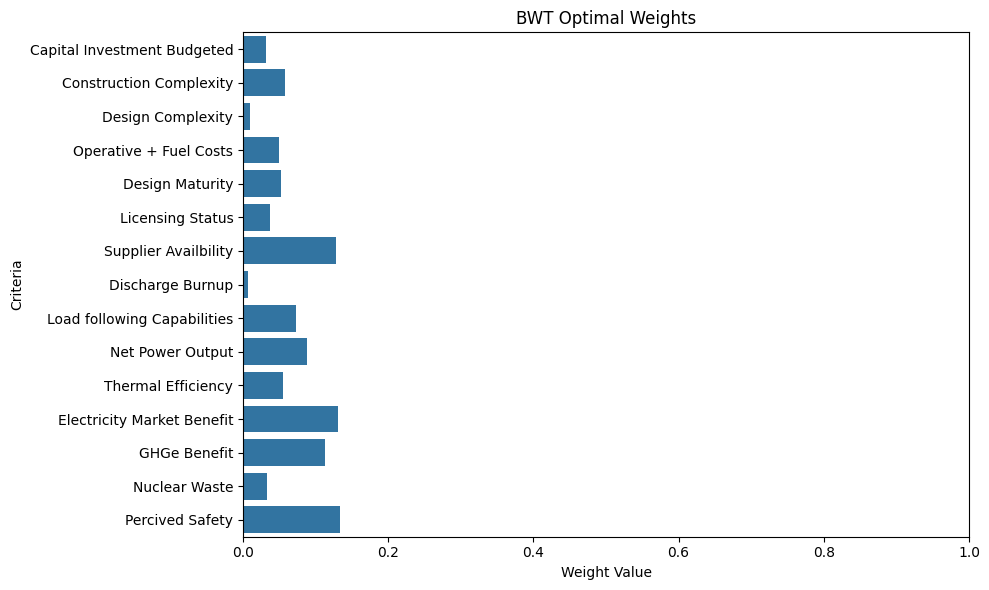

In [4]:
# Plot the BWT weights as horizontal bars
plt.figure(figsize=(10, 6))
sns.barplot(y=list(crit_index.keys()), x=x_weights, orient='h')
plt.title("BWT Optimal Weights")
plt.xlabel("Weight Value")
plt.ylabel("Criteria")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
#################################################################################

In [5]:

from weight_sampling import obtain_weight_space_description
num_criteria = len(x_weights)
used_cells = set()
grid_size = np.int64(1000)
n_dimensions = num_criteria
# print("Number of dimensions for sampling:", n_dimensions)
nx = np.array([grid_size] * n_dimensions, dtype=np.int64)

initial_point = bwt_result["solver_result"]["x"][:num_criteria]
# print("Initial point for sampling:", initial_point)
initial_cell = tuple(np.clip((np.array(initial_point) * grid_size).astype(np.int64), 0, grid_size - 1))
used_cells.add(initial_cell)
valid_points = [np.array(initial_cell, dtype=np.float64) / grid_size]

print("Starting space sampling...")
print(f"Grid size: {grid_size}, Number of dimensions: {n_dimensions}")
print(f"Initial point: {initial_point}, Initial cell: {initial_cell}")


Starting space sampling...
Grid size: 1000, Number of dimensions: 15
Initial point: [0.03116773 0.05828837 0.00996394 0.04905765 0.05289511 0.03717764
 0.12837422 0.00619761 0.07247587 0.08874538 0.05442424 0.13098132
 0.11284899 0.03330406 0.13409789], Initial cell: (np.int64(31), np.int64(58), np.int64(9), np.int64(49), np.int64(52), np.int64(37), np.int64(128), np.int64(6), np.int64(72), np.int64(88), np.int64(54), np.int64(130), np.int64(112), np.int64(33), np.int64(134))


In [6]:
print(sum(initial_point))

1.0


In [7]:
print(known_max_error)

5.350100806609579


Generating weight samples for elicitation 1...
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=4.717898169914747e-07
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=5.575482466824155e-06
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=0.011489240970198544
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Trying 'COBYLA'

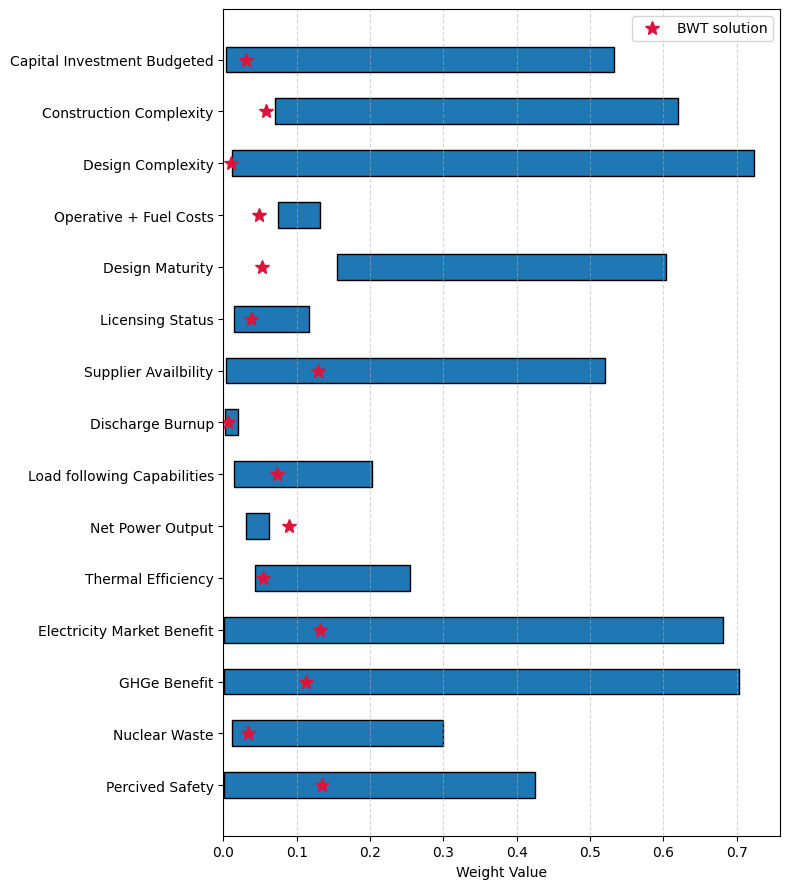

Total weight combinations to sample: -8563220167455309824 (values rounded to 3 decimals)


In [8]:
list_of_weight_space_points = obtain_weight_space_description(bwt_results, dict_data_list, file_path_weight_elicitations, crit_index)

In [9]:
# We then seelct one of the elicitated spaces
weight_space_points = list_of_weight_space_points[0]
print(weight_space_points)

[[0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02, 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027, 0.028, 0.029, 0.03, 0.031, 0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.04, 0.041, 0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048, 0.049, 0.05, 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.06, 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08, 0.081, 0.082, 0.083, 0.084, 0.085, 0.086, 0.087, 0.088, 0.089, 0.09, 0.091, 0.092, 0.093, 0.094, 0.095, 0.096, 0.097, 0.098, 0.099, 0.1, 0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11, 0.111, 0.112, 0.113, 0.114, 0.115, 0.116, 0.117, 0.118, 0.119, 0.12, 0.121, 0.122, 0.123, 0.124, 0.125, 0.126, 0.127, 0.128, 0.129, 0.13, 0.131, 0.132, 0.133, 0.134, 0.135, 0.136, 0.137, 0.138, 0.139, 0.14, 0.141, 0.142, 0.143, 0.144, 0.145, 0.146, 0.147, 0.148

In [10]:
from weight_sampling import weight_sampler
weight_sampler(dict_data, weight_space_points)

KeyboardInterrupt: 